## Analysis of EuRepoC Reported Cyber Incidents 
# Goal is to use NLP and machine learning to predict target countries of cyber attacks
Dataset: eurepoc_dyadic_dataset_0_1.csv

Which latent types of cyber operations emerge from incident descriptions, and how do these topics differ in intensity, impact, and political response? Are geopolitical cyber-conflict topics (Russia-Ukraine, Iran-Israel, China/APT, North Korea) associated with systematically different intensity levels and political responses?

1. Clean attack descriptions
2. Generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Topic discovery
5. Relationship with weighted intensity


Old Idea 1: Map the evolution of state-sponsord cyber operations from 2000-2024 using BERTopic and transformer embeddings.

1. Clean attack descriptions
2. generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Extract countries and organizations (spaCy)
5. Track topics over time
6. Build attack-type classifier
7. Visualize geopolitical networks

Old Idea 2: Predict receiver country based on initiating country, operation type, source disclosure (reported by whom), data theft, disruption, hijacking, ransomware, doxxing, physical effects (spatial, temporal), weighted cyber intensity (higher weightings for politically motivated attacks), impact indicator (sum of individual impact scores), political impact, intelligence impact, economic impact, number political responses, number legal responses

In [ ]:
import pandas as pd
import html
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP
import random
import numpy as np
import spacy
from src.nlp_functions import(remove_geo_entities)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pio.renderers.default = "browser"

In [ ]:
# Read in data 
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_full = pd.read_csv(url)

print(dyadic_data_full.shape)
print(dyadic_data_full.head())

In [ ]:
vars_to_check = [
    "impact_indicator_score",
    "weighted_intensity",
    "unweighted_intensity",
    "economic_impact",
    "functional_impact",
    "intelligence_impact"
]

for var in vars_to_check:
    print(f"\n{'='*60}")
    print(f"Value counts for: {var}")
    print(f"{'='*60}")
    print(dyadic_data_full[var].value_counts(dropna=False).sort_index())

In [ ]:
# Isolate columns of interest
drop_vars = ["added_to_db","updated_at","attribution_id",\
    "initiator_alpha_2","receiver_country_alpha_2_code",
    "Data theft","Data theft & Doxing","Disruption",
    "Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]

attack_labels = ["Data theft","Data theft & Doxing", \
    "Disruption","Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]
attack_data = dyadic_data_full[["incident_id"] + attack_labels].copy()

dyadic_data = dyadic_data_full.drop(columns=drop_vars,\
    errors="ignore")

print(f"Original shape: {dyadic_data_full.shape}")
print(f"New shape: {dyadic_data.shape}")

print("\nRemaining columns:")
print(dyadic_data.columns.tolist())


In [ ]:
# Check for missing values in descriptions
print(dyadic_data["description"].isnull().sum())
print(dyadic_data[dyadic_data["description"]==""])

In [665]:
# Incident-level dataset for NLP
# Descriptions can be duplicated because of the dyadic nature of the dataset. 
# One incident may span several rows if it affected several countries. 
incident_text_data = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)
print(incident_text_data.head())


    dyad_id initiator_country receiver_country  incident_id  \
1         1       Afghanistan         Pakistan          488   
2         1       Afghanistan         Pakistan          499   
3         2           Algeria          Algeria          525   
5         3           Algeria           France          866   
10        8         Argentina        Argentina          529   

                                                 name  \
1                Afghan Cyber Army attack on Pakistan   
2        Afghan Cyber Army attack on Pakistan Part II   
3             Over-X vs. Algerian ministry of housing   
5         TeamSystemDz defacement of western websites   
10  Team HackingArgentino defaces Website of Argen...   

                                          description           start_date  \
1   Afghan hackers deface six Pakistani government...  2013-07-11 00:00:00   
2   Afghan hackers hack the webpage of the Pakista...  2013-08-03 00:00:00   
3   Algerian hacker Over-X hacks and defaces

In [666]:
# Clean description
incident_text_data["description"] = (
    incident_text_data["description"] 
    .fillna("")
    .astype(str)
    .apply(html.unescape)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
# Identify missing descriptions
print(incident_text_data["description"].isna().sum())

# Empty descriptions
print((incident_text_data["description"] == "").sum())

# Length distribution
incident_text_data["n_words"] = (
    incident_text_data["description"]
    .str.split()
    .str.len()
)

print(incident_text_data["n_words"].describe())

incident_text_data.loc[
    incident_text_data["n_words"] < 5,
    ["incident_id", "description"]
].head(20)


0
0
count    1609.000000
mean       75.389683
std        68.252689
min         6.000000
25%        26.000000
50%        60.000000
75%       102.000000
max       910.000000
Name: n_words, dtype: float64


,incident_id,description


In [ ]:
# Check how many short descriptions would be lost if filtered out
print((incident_text_data["n_words"] < 5).sum())
print((incident_text_data["n_words"] < 10).sum())

0
64


In [669]:
# Filter out descriptions with less than five words
incident_text_data = incident_text_data[incident_text_data["n_words"] > 5]

In [ ]:
# Remove geographic terms from text
nlp = spacy.load("en_core_web_sm")

incident_text_data["description_no_geo"] = (
    incident_text_data["description"]
    .apply(lambda x: remove_geo_entities(x, nlp))
)

incident_text_data["description_no_geo"] = (
    incident_text_data["description"]
    .apply(remove_geo_entities)
)

In [671]:
# Sentence embeddings with BERT
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    incident_text_data["description_no_geo"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 51/51 [00:01<00:00, 42.66it/s]


In [672]:
# Generic stopwords 
cyber_stopwords = [
    "attack",
    "attacks",
    "attacker",
    "hack",
    "hacks",
    "hacked",
    "hacker",
    "hackers",
    "hacking",
    "campaign",
    "group",
    "security",
    "incident",
    "reported",
    "report",
    "unknown"
]

vectorizer_model = CountVectorizer(
    stop_words=cyber_stopwords,
    min_df=5,
    ngram_range=(1, 3)
)

In [673]:
# Get rid of stopwords, BERT wasn't using them effectively
#vectorizer_model = CountVectorizer(
#    stop_words="english",
#    min_df=5,
#    ngram_range=(1, 3)
#)

# BERTopic analysis 
# For reproducibility 
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
) 

# For more readable labels
representation_model = KeyBERTInspired()


# Build topic model 
topic_model = BERTopic(
    embedding_model=model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    min_topic_size=20,
    calculate_probabilities=True
)


topics, probs = topic_model.fit_transform(
    incident_text_data["description_no_geo"],
    embeddings
)

topic_model = topic_model.reduce_topics(
    incident_text_data["description_no_geo"],
    nr_topics="auto"
)

topics = topic_model.topics_

In [686]:
# Examine topics
topic_info = topic_model.get_topic_info()
#print(topic_info.head())

topic_info[["Topic", "Count", "Representation"]]\
    .style.set_table_attributes(
        'style="display:block;max-height:500px;overflow:auto;"'
    )

topic_model.save("eurepoc_final_model")

2026-08-19 11:19:38,000 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [687]:
# Add topic info to deduplicated dataset
incident_text_data["topic"] = topics
incident_text_data["topic_prob"] = probs.max(axis=1)

# Create a look-up table
topic_lookup = incident_text_data[
    ["incident_id", "topic"]
].copy()

# Create interpretable topic labels
topic_info = topic_model.get_topic_info()

topic_labels = (
    topic_info[["Topic", "Representation"]]
    .copy()
)

topic_labels["topic_label"] = (
    topic_labels["Representation"]
    .apply(lambda x: ", ".join(x[:5]))
)

# Merge topics onto dyadic data
dyadic_data = dyadic_data_full.drop(
    columns=drop_vars,
    errors="ignore"
).copy()

dyadic_data = dyadic_data.merge(
    topic_lookup,
    on="incident_id",
    how="left"
)

dyadic_data = dyadic_data.merge(
    topic_labels[["Topic", "topic_label"]],
    left_on="topic",
    right_on="Topic",
    how="left"
)

dyadic_data = dyadic_data.dropna(
    subset=["topic"]
).copy()

print(dyadic_data["topic"].isna().sum())
print(dyadic_data["topic"].value_counts().head())


0
topic
2.0    644
0.0    352
1.0    249
3.0    227
4.0    158
Name: count, dtype: int64


In [688]:
print(
    dyadic_data[
        ["topic", "topic_label"]
    ].drop_duplicates()
    .sort_values("topic")
)

      topic                                        topic_label
271    -1.0  compromised, phishing, an investigation, inves...
1       0.0  anonymous, website of the, website, website of...
97      1.0    ddos, hacktivist, disruptions, disrupted, cyber
112     2.0  malware, the malware, vulnerabilities, malicio...
18      3.0  leaked data, compromised, sensitive data, espi...
11      4.0  the ransomware, ransomware, ransomware on, ran...
426     5.0  data breach, stolen data, the stolen data, com...
1373    6.0  ransomware on, ransomware, ransom, compromised...
1399    7.0  the ransomware, ransomware, ransom, compromise...
1119    8.0  exploited vulnerability, exploited, the theft ...
1401    9.0  data breach, the data breach, breach, the brea...
71     10.0  malware, the malware, espionage, nsa, the it c...
41     11.0  espionage, the investigation, investigation, s...
1457   12.0  actors gained access, the network, disrupted t...


In [689]:
# Remove outliers
dyadic_data = dyadic_data[
    dyadic_data["topic"] != -1
].copy()

In [707]:
# Create more readable topic names from topic labels
topic_names = {
    "compromised, phishing, an investigation, investigation, gained access":
        "Mixed Intrusions & Investigations",

    "anonymous, website of the, website, website of, site":
        "Website Defacement & Hacktivism",

    "ddos, hacktivist, disruptions, disrupted, cyber":
        "DDoS & Service Disruption Campaigns",

    "malware, the malware, vulnerabilities, malicious, compromised":
        "Malware Operations",

    "leaked data, compromised, sensitive data, espionage, leaked":
        "Cyber Espionage & Data Leaks",

    "the ransomware, ransomware, ransomware on, ransom, with ransomware":
        "Ransomware & Cyber Extortion",

    "data breach, stolen data, the stolen data, compromised, breached":
        "Data Breaches",

    "ransomware on, ransomware, ransom, compromised, intrusion":
        "Institutional Ransomware Attacks",

    "the ransomware, ransomware, ransom, compromised, data":
        "Double-Extortion Ransomware",

    "exploited vulnerability, exploited, the theft of, theft of, theft":
        "Vulnerability Exploitation",

    "data breach, the data breach, breach, the breach, healthcare":
        "Healthcare Data Breaches",

    "malware, the malware, espionage, nsa, the it company":
        "Government Intelligence Operations",

    "espionage, the investigation, investigation, suspected, forensic":
        "Surveillance & Mobile Espionage",

    "actors gained access, the network, disrupted the, disrupted, the networks":
        "Network Intrusions"
}

dyadic_data["topic_name"] = (
    dyadic_data["topic_label"]
    .map(topic_names)
)

topic_groups = {
    "Website Defacement & Hacktivism": "Disruption",
    "DDoS & Service Disruption Campaigns": "Disruption",

    "Malware Operations": "Intrusion",
    "Vulnerability Exploitation": "Intrusion",
    "Network Intrusions": "Intrusion",

    "Cyber Espionage & Data Leaks": "Information Operations",
    "Surveillance & Mobile Espionage": "Information Operations",
    "Government Intelligence Operations": "Information Operations",

    "Data Breaches": "Data Exposure",
    "Healthcare Data Breaches": "Data Exposure",

    "Ransomware & Cyber Extortion": "Financially Motivated",
    "Institutional Ransomware Attacks": "Financially Motivated",
    "Double-Extortion Ransomware": "Financially Motivated",

    "Mixed Intrusions & Investigations": "Other"
}

dyadic_data["topic_group"] = (
    dyadic_data["topic_name"]
    .map(topic_groups)
)

print(
    dyadic_data[
        ["topic", "topic_label", "topic_name","topic_group"]
    ]
    .drop_duplicates()
    .sort_values("topic")
)

      topic                                        topic_label  \
1       0.0  anonymous, website of the, website, website of...   
97      1.0    ddos, hacktivist, disruptions, disrupted, cyber   
112     2.0  malware, the malware, vulnerabilities, malicio...   
18      3.0  leaked data, compromised, sensitive data, espi...   
11      4.0  the ransomware, ransomware, ransomware on, ran...   
426     5.0  data breach, stolen data, the stolen data, com...   
1373    6.0  ransomware on, ransomware, ransom, compromised...   
1399    7.0  the ransomware, ransomware, ransom, compromise...   
1119    8.0  exploited vulnerability, exploited, the theft ...   
1401    9.0  data breach, the data breach, breach, the brea...   
71     10.0  malware, the malware, espionage, nsa, the it c...   
41     11.0  espionage, the investigation, investigation, s...   
1457   12.0  actors gained access, the network, disrupted t...   

                               topic_name             topic_group  
1      

In [708]:
# Topic vs intensity
dyadic_data.groupby("topic_group")["weighted_intensity"]\
    .mean()\
    .sort_values(ascending=False)

topic_group
Financially Motivated     3.664756
Data Exposure             3.113402
Intrusion                 2.556452
Information Operations    2.407407
Disruption                1.389351
Name: weighted_intensity, dtype: float64

In [710]:
# Topic vs political responses
dyadic_data.groupby("topic_group")["number_political_responses"]\
    .mean()\
    .sort_values(ascending=False)

topic_group
Intrusion                 0.151882
Disruption                0.114809
Financially Motivated     0.114613
Data Exposure             0.113402
Information Operations    0.031339
Name: number_political_responses, dtype: float64

In [711]:
# Most common receiver countries by topic
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_group"]
)

topic_group,Data Exposure,Disruption,Financially Motivated,Information Operations,Intrusion
receiver_country,,,,,
Afghanistan,0,2,0,3,11
Africa,0,0,0,2,5
Albania,0,1,0,0,1
Algeria,0,1,0,0,0
Angola,0,2,0,0,0
...,...,...,...,...,...
Venezuela,0,5,1,0,1
Vietnam,0,2,2,6,14
Western Europe,0,0,0,0,4


## Visualizations

In [712]:
# What cyber conflict themes dominate the dataset?
topic_counts = (
    dyadic_data["topic_group"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topic", "count"]

fig = px.treemap(
    topic_counts,
    path=["topic"],
    values="count",
    title="Distribution of Cyber Conflict Topics"
)

fig.show()

fig.write_html("topic_treemap.html")

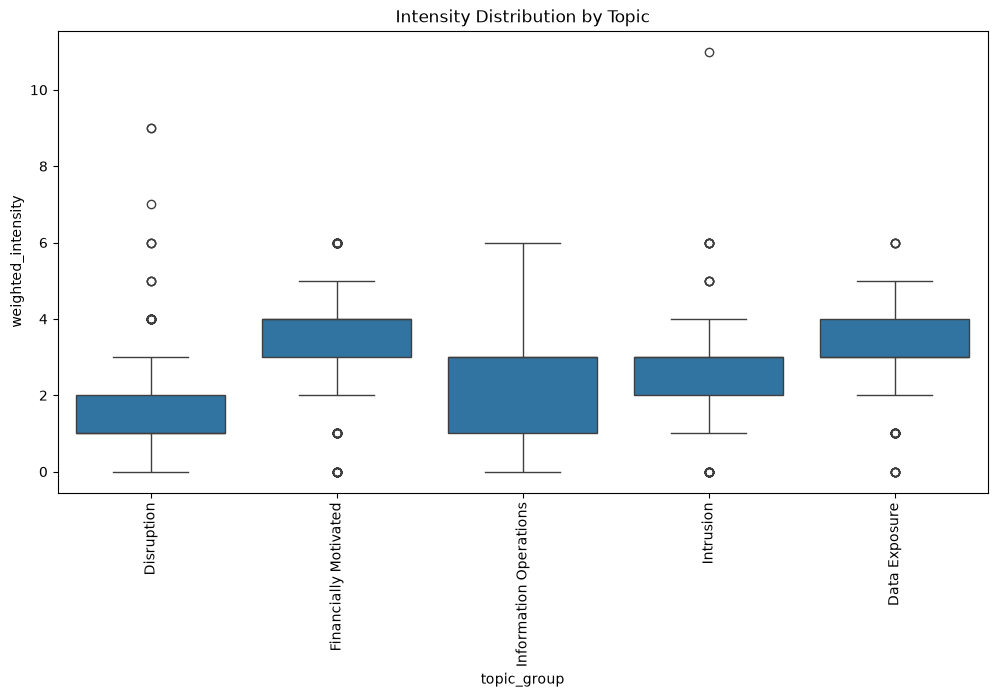

In [713]:
# What cyber conflicts are most intense?
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dyadic_data,
    x="topic_group",
    y="weighted_intensity"
)

plt.xticks(rotation=90)
plt.title("Intensity Distribution by Topic")
plt.show()

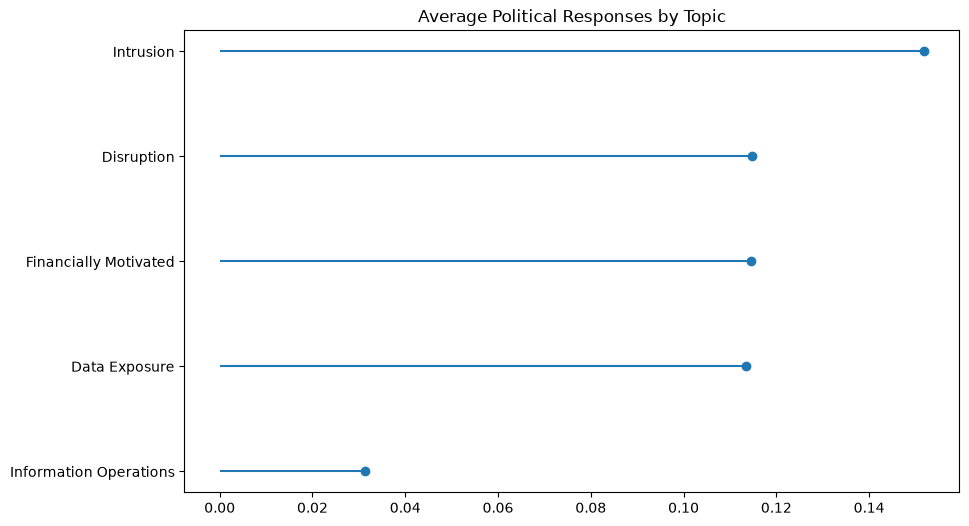

In [714]:
# What cyber conflicts trigger political reactions?
responses = (
    dyadic_data.groupby("topic_group")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic")
plt.show()

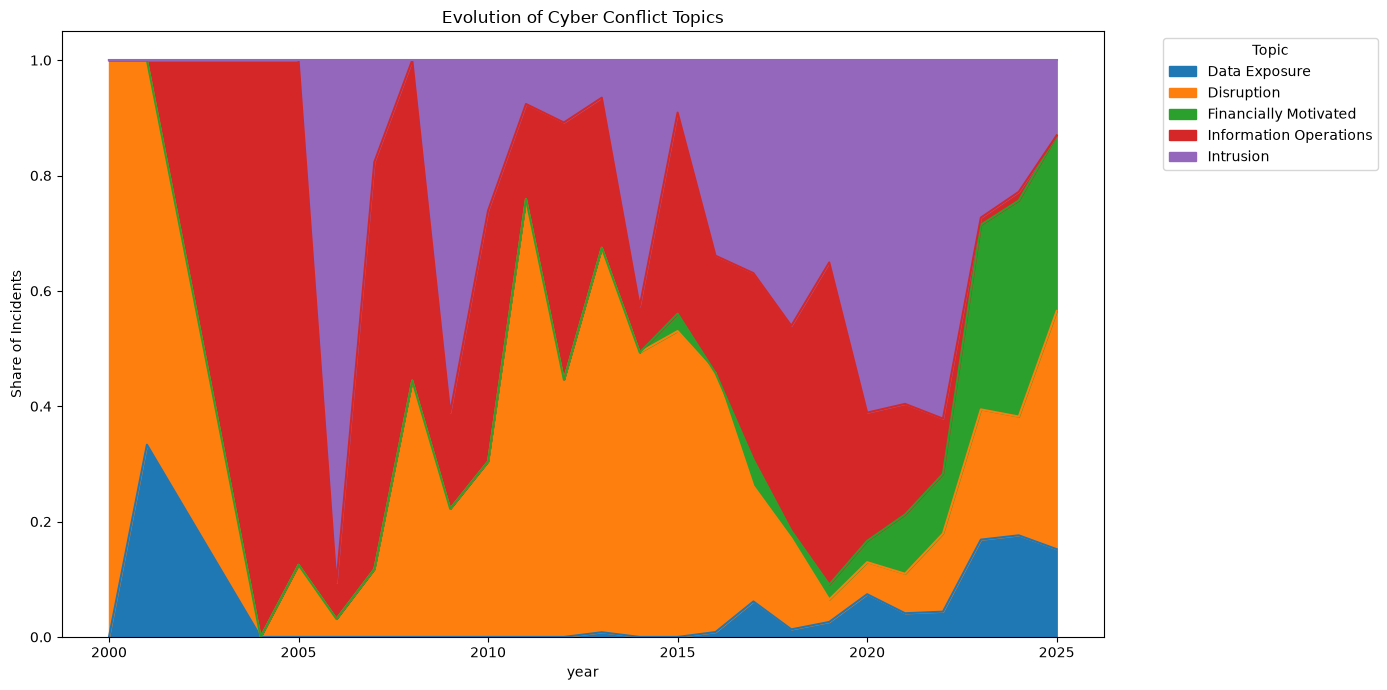

In [715]:
# How has the nature of cyber conflict changed over time?
dyadic_data["year"] = pd.to_datetime(
    dyadic_data["start_date"],
    errors="coerce"   # invalid dates become NaT
).dt.year

topic_year = pd.crosstab(
    dyadic_data["year"],
    dyadic_data["topic_group"],
    normalize="index"
)

fig, ax = plt.subplots(figsize=(14, 7))

topic_year.plot.area(ax=ax)

ax.set_title("Evolution of Cyber Conflict Topics")
ax.set_ylabel("Share of Incidents")

ax.legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


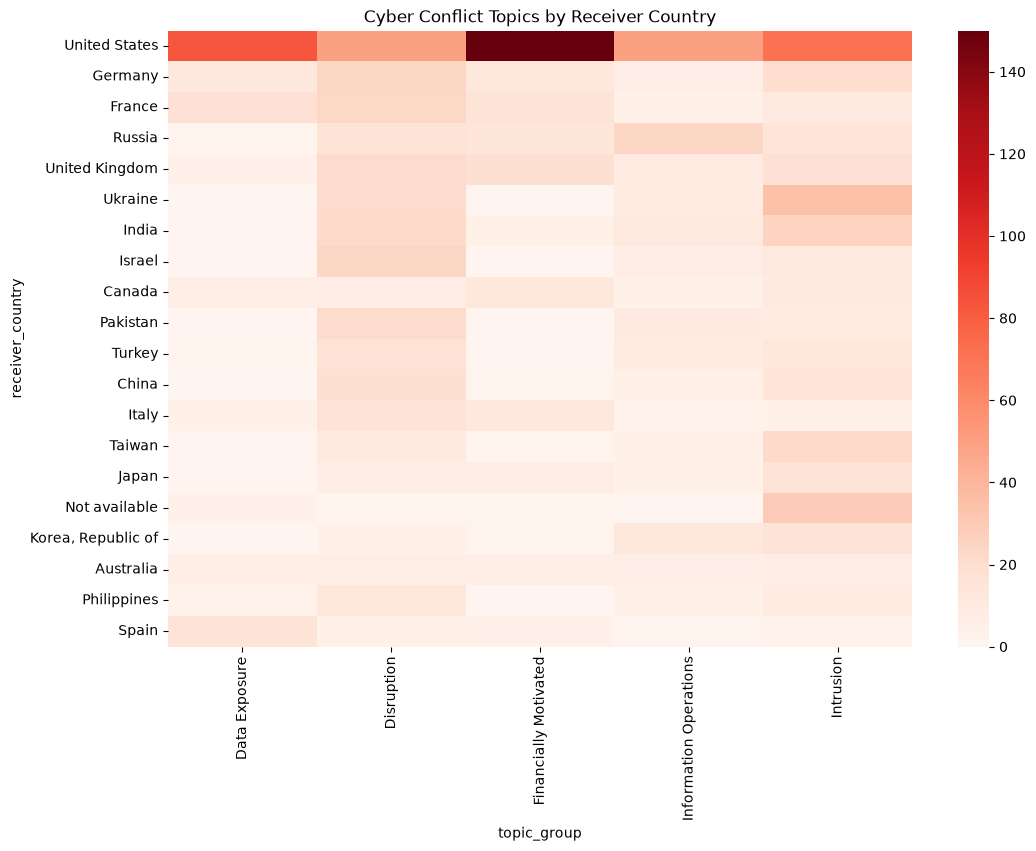

In [717]:
# Which countries are disproportinately affected by certain types of cyber attacks?
country_topic = pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_group"]
)

top_countries = (
    country_topic.sum(axis=1)
    .nlargest(20)
    .index
)

plt.figure(figsize=(12,8))

sns.heatmap(
    country_topic.loc[top_countries],
    cmap="Reds"
)

plt.title("Cyber Conflict Topics by Receiver Country")
plt.show()

In [718]:
# Filters for sankey visual
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

sankey_data = dyadic_data[
    dyadic_data["initiator_country"].isin(top_initiators)
    &
    dyadic_data["receiver_country"].isin(top_receivers)
].copy()

In [725]:
# Shorten topic labels
sankey_data["short_topic"] = (
    sankey_data["topic_group"]
    .str.split(",")
    .str[:3]
    .str.join(", ")
)

In [726]:
# Create flows
# Initiator -> Topic
flow1 = (
    sankey_data
    .groupby(
        ["initiator_country", "short_topic"]
    )
    .size()
    .reset_index(name="value")
)

# Topic -> Reciever
flow2 = (
    sankey_data
    .groupby(
        ["short_topic", "receiver_country"]
    )
    .size()
    .reset_index(name="value")
)

In [727]:
# Build node list
nodes = list(
    pd.concat([
        flow1["initiator_country"],
        flow1["short_topic"],
        flow2["receiver_country"]
    ]).unique()
)

node_dict = {
    node: i
    for i, node in enumerate(nodes)
}

In [728]:
# Build link table
source = []
target = []
value = []

# Initiator -> Topic
for _, row in flow1.iterrows():
    source.append(
        node_dict[row["initiator_country"]]
    )
    target.append(
        node_dict[row["short_topic"]]
    )
    value.append(row["value"])

# Topic -> Receiver
for _, row in flow2.iterrows():
    source.append(
        node_dict[row["short_topic"]]
    )
    target.append(
        node_dict[row["receiver_country"]]
    )
    value.append(row["value"])

In [729]:
fig = go.Figure(
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Cyber Conflict Flows: Initiator → Topic → Receiver",
    font_size=10
)

fig.show()

In [705]:
topic_summary = (
    dyadic_data
    .groupby("topic_name")
    .agg(
        incidents=("incident_id", "count"),
        avg_intensity=("weighted_intensity", "mean"),
        avg_political=("number_political_responses", "mean"),
        avg_legal=("number_legal_responses", "mean")
    )
    .round(2)
)

In [706]:
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_name"],
    normalize="index"
)

topic_name,Cyber Espionage & Data Leaks,DDoS & Service Disruption Campaigns,Data Breaches,Double-Extortion Ransomware,Government Intelligence Operations,Healthcare Data Breaches,Institutional Ransomware Attacks,Malware Operations,Network Intrusions,Ransomware & Cyber Extortion,Surveillance & Mobile Espionage,Vulnerability Exploitation,Website Defacement & Hacktivism
receiver_country,,,,,,,,,,,,,
Afghanistan,0.062500,0.0,0.0,0.000000,0.125000,0.0,0.0,0.687500,0.0,0.000000,0.0,0.000000,0.125000
Africa,0.142857,0.0,0.0,0.000000,0.142857,0.0,0.0,0.571429,0.0,0.000000,0.0,0.142857,0.000000
Albania,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.500000,0.0,0.000000,0.0,0.000000,0.500000
Algeria,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,1.000000
Angola,0.000000,0.5,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,0.000000,0.0,0.0,0.142857,0.000000,0.0,0.0,0.142857,0.0,0.000000,0.0,0.000000,0.714286
Vietnam,0.166667,0.0,0.0,0.000000,0.083333,0.0,0.0,0.583333,0.0,0.083333,0.0,0.000000,0.083333
Western Europe,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,1.000000,0.0,0.000000,0.0,0.000000,0.000000
